In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [2]:
## State
class LoanState(TypedDict):
    applicant_name: str
    age: int
    monthly_income: float
    monthly_debt: float
    credit_score: int
    employee_years: float
    required_documents: list[str]
    submitted_documents: list[str]

    validated: bool
    validation_message: str
    processed_income: float
    processed_debt: float

    credit_category: str
    dti_ratio: float
    income_stability: str

    risk_factors: dict
    overall_risk: str

    decision: str
    missing_documents: list[str]
    review_attempt: int
    review_message: str
    final_decision: str

In [3]:
### validate_applicant
def validate_applicant(state: LoanState):
    print("\n--- Validate Applicant ---")
    if state["age"]<18:
        return{
            "validated" : False,
            "validation_message": "Applicant must be at least 18 years old"
        }

    if state["monthly_income"] <= 0:
        return{
            "validated":False,
            "validation_message":"Applicant's monthly income must be greater than 0."
        }
    if state["monthly_debt"] < 0:
        return{
            "validated": False,
            "validation_message": "Monthly debt must not be less than zero."
        }    
    if state["credit_score"] < 300 and state["credit_score"] >= 850:
        return{
            "validated":False,
            "validation_message": "Invalid credit score."
        }
    return{
        "validated":True,
        "validation_message":"Applicant is validated."
    }

In [4]:
### preprocess_applicant
def preprocess_applicant(state: LoanState):
    print("\n --- Preprocess Applicant ---")
    income = float(state["monthly_income"])
    debt = float(state["monthly_debt"])
    return{
        "processed_income":"income",
        "processed_debt":"debt"
    }

In [5]:
### credit score category
def calculate_credit_category(state:LoanState):
    print("\n --- Calculate Credit history ---")
    score = state["credit_score"]
    if score >= 750:
        category = "Excellent"
    elif score >= 700:
        category = "Good"
    elif score >= 650:
        category = "Fair"
    else: 
        category="Poor"
    return {
        "credit_category":category
    }

In [6]:
### debt-to-income ratio
def calculate_dti(state: LoanState):
    print("\n --- Calculate debt-to-income ratio ---")
    income = state["processed_income"]
    debt = state["processed_debt"]
    dti = (debt/income)*100
    return{
        "dti_ratio": dti
    }

In [7]:
### income stability
def calculate_income_stability(state: LoanState):
    print("\n --- Calculate Income stability ---")
    employment_years = state["employment_years"]
    if employment_years >= 5:
        stability = "High"
    elif employment_years >=2:
        stability = "Medium"
    else:
        stability = "Low"
    return{
        "income_stability": stability
    }


In [8]:
## combine results
def combine_results(state:LoanState):
    print("\n --- Combine Results ---")
    risk_factors = {
        "credit_category":state["credit_category"],
        "dti_ratio":state["dti_ratio"],
        "income_stability":state["income_stability"]
    }
    return{
        "risk_factors":risk_factors
    }

In [9]:
def assess_risk(state: LoanState):

    print("\n--- assess_risk ---")

    credit = state["credit_category"]
    dti = state["dti_ratio"]
    stability = state["income_stability"]

    # High-risk conditions
    if (
        credit == "Poor"
        or dti > 50
        or stability == "Low"
    ):
        risk = "High"

    # Low-risk conditions
    elif (
        credit in ["Excellent", "Good"]
        and dti <= 30
        and stability == "High"
    ):
        risk = "Low"

    # Everything else
    else:
        risk = "Medium"

    return {
        "overall_risk": risk
    }

In [10]:
## approve loan
def approve_loan(state: LoanState):
    return{
        "decision":"Approved"
    }

In [11]:
## reject loan
def reject_loan(state: LoanState):
    return{
        "decision":"Rejected"
    }

In [12]:
## manual review
def manual_review(state: LoanState):
    required = set(state["required_documents"])
    submitted = set(state["submitted_documents"])
    missing = list(required-submitted)
    attempt = state.get("review_attempt",0)+1
    if missing:
        return{"decision": "Manual Review",
            "missing_documents": missing,
            "review_attempt": attempt,
            "review_message": (
                f"Missing documents: {', '.join(missing)}"
            )
        }
    return {
        "decision": "Manual Review",
        "missing_documents": [],
        "review_attempt": attempt,
        "review_message": "All required documents are available."
    }

In [13]:
def check_documents(state: LoanState):

    print("\n--- check_documents ---")

    missing = state.get("missing_documents", [])

    if not missing:
        print("All documents are available.")
        return {
            "review_message": "Document verification completed."
        }

    print(f"Still missing: {missing}")

    # For practice, simulate receiving one missing document
    submitted = list(state["submitted_documents"])

    next_document = missing[0]

    if next_document not in submitted:
        submitted.append(next_document)

    return {
        "submitted_documents": submitted
    }

In [14]:
def route_risk(state: LoanState):
    risk = state["overall_risk"]
    if risk == "Low":
        return "approve"
    elif risk == "Medium":
        return "manual_review"
    else:
        return "reject"

In [15]:
def route_documents(state: LoanState):
    missing = state.get("missing_documents", [])
    if not missing:
        return "generate_decision"
    return "check_documents"

In [16]:
def generate_decision(state: LoanState):
    risk = state["overall_risk"]
    if risk == "Low":
        final = (
            f"Loan Approved for {state['applicant_name']}. "
            f"Risk Level: {risk}."
        )
    elif risk == "High":
        final = (
            f"Loan Rejected for {state['applicant_name']}. "
            f"Risk Level: {risk}."
        )
    else:
        final = (
            f"Loan Approved after Manual Review for "
            f"{state['applicant_name']}. "
            f"Risk Level: {risk}. "
            f"All required documents have been verified."
        )
    return {
        "final_decision": final
    }


In [17]:
graph = StateGraph(LoanState)

In [18]:
graph.add_node("validate_applicant",validate_applicant)
graph.add_node("preprocess_applicant",preprocess_applicant)
graph.add_node("calculate_credit_category",calculate_credit_category)
graph.add_node("calculate_dti",calculate_dti)
graph.add_node("calculate_income_stability",calculate_income_stability)
graph.add_node("combine_results",combine_results)
graph.add_node("assess_risk",assess_risk)
graph.add_node("approve_loan",approve_loan)
graph.add_node("reject_loan",reject_loan)
graph.add_node("manual_review",manual_review)
graph.add_node("generate_decision",generate_decision)
graph.add_node("check_documents", check_documents)

In [20]:
# Sequential
graph.add_edge(START, "validate_applicant")
graph.add_edge("validate_applicant", "preprocess_applicant")
graph.add_edge("preprocess_applicant","calculate_credit_category")
graph.add_edge("preprocess_applicant","calculate_dti")
graph.add_edge("preprocess_applicant","calculate_income_stability")
graph.add_edge("calculate_credit_category","combine_results")
graph.add_edge("calculate_dti","combine_results")
graph.add_edge("calculate_income_stability","combine_results")
graph.add_edge("combine_results","assess_risk")
graph.add_conditional_edges("assess_risk",route_risk,
    {
        "approve": "approve_loan",
        "manual_review": "manual_review",
        "reject": "reject_loan"
    }
)
graph.add_edge("approve_loan", "generate_decision")
graph.add_edge("reject_loan", "generate_decision")
graph.add_edge("manual_review","check_documents")
graph.add_conditional_edges("check_documents",route_documents,
    {
        "check_documents": "manual_review",
        "generate_decision": "generate_decision"
    }
)
graph.add_edge( "generate_decision",END)


In [21]:
app = graph.compile()

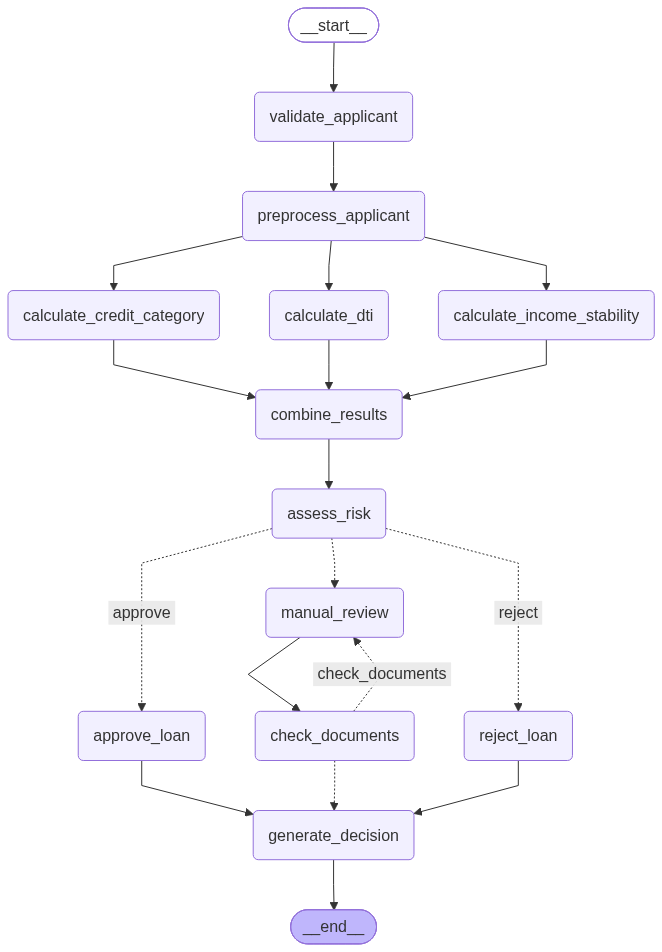

In [22]:
## workflow visualization
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))